In [215]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

In [193]:
data = pd.read_csv('../bitcoin_data/BTCUSDT_1d_2020_present.csv')
data.head()

,date,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
0,2020-01-01,7195.24,7255.0,7175.15,7200.85,16792.388165,1.212145e+08,194010.0,8946.955535,6.459779e+07
1,2020-01-02,7200.77,7212.5,6924.74,6965.71,31951.483932,2.259823e+08,302667.0,15141.611340,1.070608e+08
2,2020-01-03,6965.49,7405.0,6871.04,7344.96,68428.500451,4.950986e+08,519854.0,35595.496273,2.577131e+08
3,2020-01-04,7345.00,7404.0,7272.21,7354.11,29987.974977,2.198742e+08,279370.0,16369.382248,1.200351e+08
4,2020-01-05,7354.19,7495.0,7318.00,7358.75,38331.085604,2.848487e+08,329209.0,19455.369564,1.446001e+08


In [194]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2361 entries, 0 to 2360
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date                          2361 non-null   str    
 1   open                          2361 non-null   float64
 2   high                          2361 non-null   float64
 3   low                           2361 non-null   float64
 4   close                         2361 non-null   float64
 5   volume                        2361 non-null   float64
 6   quote_asset_volume            2361 non-null   float64
 7   number_of_trades              2361 non-null   float64
 8   taker_buy_base_asset_volume   2361 non-null   float64
 9   taker_buy_quote_asset_volume  2361 non-null   float64
dtypes: float64(9), str(1)
memory usage: 184.6 KB


In [195]:
df = data.copy()

* Convert date from string to datetime

In [196]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

* Bitcoin Pattern Features

In [197]:
import numpy as np

# Candle direction
df["candle_green"] = (df["close"] > df["open"]).astype(int)

# Candle body
df["body"] = df["close"] - df["open"]
df["body_pct"] = (df["close"] - df["open"]) / df["open"]

# Candle range
df["range"] = df["high"] - df["low"]
df["range_pct"] = (df["high"] - df["low"]) / df["open"]

# Upper wick
df["upper_wick"] = df["high"] - df[["open", "close"]].max(axis=1)
df["upper_wick_pct"] = df["upper_wick"] / df["open"]

# Lower wick
df["lower_wick"] = df[["open", "close"]].min(axis=1) - df["low"]
df["lower_wick_pct"] = df["lower_wick"] / df["open"]

# Close position inside daily candle
df["close_position"] = (df["close"] - df["low"]) / (df["high"] - df["low"])

# Daily return
df["return_1d"] = df["close"].pct_change()

# Log return
df["log_return"] = np.log(df["close"] / df["close"].shift(1))

* Create volume and buying-pressure features

In [198]:
# Volume changes
df["volume_change"] = df["volume"].pct_change()
df["quote_volume_change"] = df["quote_asset_volume"].pct_change()

# Log volume
df["log_volume"] = np.log1p(df["volume"])
df["log_quote_volume"] = np.log1p(df["quote_asset_volume"])

# Buy pressure
df["buy_base_ratio"] = df["taker_buy_base_asset_volume"] / df["volume"]
df["buy_quote_ratio"] = df["taker_buy_quote_asset_volume"] / df["quote_asset_volume"]

# Average trade size
df["avg_trade_size"] = df["volume"] / df["number_of_trades"]

# Trade activity change
df["trade_count_change"] = df["number_of_trades"].pct_change()

* Create moving-average and momentum features

In [199]:
# Moving averages
df["ma_7"] = df["close"].rolling(7).mean()
df["ma_14"] = df["close"].rolling(14).mean()
df["ma_30"] = df["close"].rolling(30).mean()

# Price distance from moving averages
df["close_ma7_ratio"] = df["close"] / df["ma_7"]
df["close_ma14_ratio"] = df["close"] / df["ma_14"]
df["close_ma30_ratio"] = df["close"] / df["ma_30"]

# Momentum
df["return_3d"] = df["close"].pct_change(3)
df["return_7d"] = df["close"].pct_change(7)
df["return_14d"] = df["close"].pct_change(14)

# Volatility
df["volatility_7d"] = df["return_1d"].rolling(7).std()
df["volatility_14d"] = df["return_1d"].rolling(14).std()
df["volatility_30d"] = df["return_1d"].rolling(30).std()

In [200]:
simple_lag_columns = [
    "return_1d",
    "return_3d",
    "return_7d",
    "volume_change",
    "quote_volume_change",
    "buy_base_ratio",
    "buy_quote_ratio",
    "volatility_7d"
]

lags = [1, 2, 3, 5, 7, 14]

simple_lag_features = []

for col in simple_lag_columns:
    for lag in lags:
        new_col = f"{col}_lag{lag}"
        df[new_col] = df[col].shift(lag)
        simple_lag_features.append(new_col)

* Create target variable

In [201]:
df["return_pct"] = df["close"].pct_change().shift(-1) * 100
# prediction target: next-day percentage movement
df["target_pct"] = df["return_pct"].shift(-1)

* Drop Missing Values

In [202]:
# Remove missing rows
df = df.dropna().reset_index(drop=True)

In [203]:
train_df = df[df["date"] < "2024-01-01"]
val_df = df[(df["date"] >= "2024-01-01") & (df["date"] < "2025-01-01")]
test_df = df[df["date"] >= "2025-01-01"]

In [204]:
print("Train:", train_df["date"].min(), "to", train_df["date"].max(), train_df.shape)
print("Validation:", val_df["date"].min(), "to", val_df["date"].max(), val_df.shape)
print("Test:", test_df["date"].min(), "to", test_df["date"].max(), test_df.shape)

Train: 2020-01-31 00:00:00 to 2023-12-31 00:00:00 (1431, 92)
Validation: 2024-01-01 00:00:00 to 2024-12-31 00:00:00 (366, 92)
Test: 2025-01-01 00:00:00 to 2026-06-16 00:00:00 (532, 92)


<Figure size 1200x500 with 0 Axes>

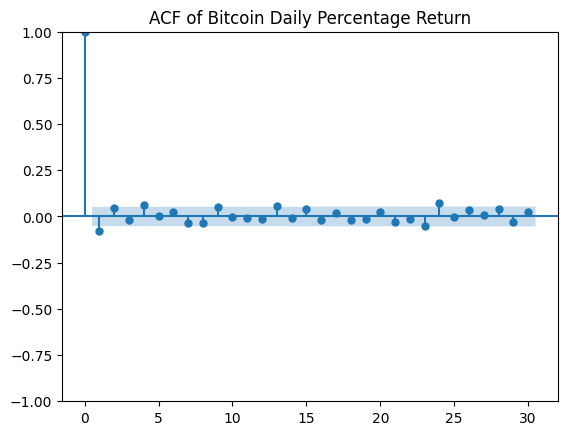

<Figure size 1200x500 with 0 Axes>

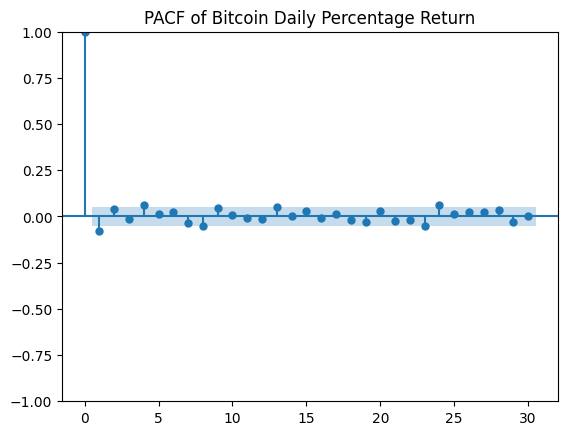

In [214]:
train_return = train_df["return_pct"]
plt.figure(figsize=(12, 5))
plot_acf(train_return, lags=30)
plt.title("ACF of Bitcoin Daily Percentage Return")
plt.show()

plt.figure(figsize=(12, 5))
plot_pacf(train_return, lags=30, method="ywm")
plt.title("PACF of Bitcoin Daily Percentage Return")
plt.show()

In [206]:
features = [
    "body_pct",
    "range_pct",
    "upper_wick_pct",
    "lower_wick_pct",
    "close_position",

    "return_1d",
    "return_3d",
    "return_7d",
    "return_14d",

    "volume_change",
    "quote_volume_change",
    "log_volume",
    "log_quote_volume",

    "buy_base_ratio",
    "buy_quote_ratio",

    "avg_trade_size",
    "trade_count_change",

    "close_ma7_ratio",
    "close_ma14_ratio",
    "close_ma30_ratio",

    "volatility_7d",
    "volatility_14d",
    "volatility_30d"
]
features = features + simple_lag_columns
target = "target_pct"

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [207]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

val_pred = model.predict(X_val)

val_mae = mean_absolute_error(y_val, val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
val_r2 = r2_score(y_val, val_pred)

print("Validation MAE:", val_mae)
print("Validation RMSE:", val_rmse)
print("Validation R2:", val_r2)

Validation MAE: 2.014271588403305
Validation RMSE: 2.777067735050289
Validation R2: -0.007024034532111978


In [208]:
# Combine train + validation for final training
train_val_df = pd.concat([train_df, val_df], axis=0)

X_train_val = train_val_df[features]
y_train_val = train_val_df[target]

final_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_val, y_train_val)

test_pred = final_model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2 = r2_score(y_test, test_pred)

print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)

Test MAE: 1.6445024415120195
Test RMSE: 2.3273602809040694
Test R2: -0.0005316867362541444


In [209]:
# Baseline 1: always predict 0% movement
baseline_zero = np.zeros(len(y_test))

print("Baseline 0% MAE:", mean_absolute_error(y_test, baseline_zero))
print("Baseline 0% RMSE:", np.sqrt(mean_squared_error(y_test, baseline_zero)))
print("Baseline 0% R2:", r2_score(y_test, baseline_zero))

# Baseline 2: always predict training average movement
baseline_mean = np.full(len(y_test), y_train_val.mean())

print("Baseline mean MAE:", mean_absolute_error(y_test, baseline_mean))
print("Baseline mean RMSE:", np.sqrt(mean_squared_error(y_test, baseline_mean)))
print("Baseline mean R2:", r2_score(y_test, baseline_mean))

Baseline 0% MAE: 1.6377713588775187
Baseline 0% RMSE: 2.3273692329790028
Baseline 0% R2: -0.0005393837412537295
Baseline mean MAE: 1.6523664117830037
Baseline mean RMSE: 2.339455458341934
Baseline mean R2: -0.010958137781005073


In [210]:
direction_actual = np.sign(y_test)
direction_pred = np.sign(test_pred)

direction_accuracy = (direction_actual == direction_pred).mean()

print("Direction accuracy:", direction_accuracy)

actual_up_ratio = (y_test > 0).mean()
print("Actual up-day ratio:", actual_up_ratio)

Direction accuracy: 0.5037593984962406
Actual up-day ratio: 0.4868421052631579


In [211]:
results = test_df[["date", "close", "target_pct"]].copy()
results["predicted_pct"] = test_pred
results["actual_direction"] = np.where(results["target_pct"] > 0, "Up", "Down")
results["predicted_direction"] = np.where(results["predicted_pct"] > 0, "Up", "Down")
results["error"] = results["target_pct"] - results["predicted_pct"]
results["abs_error"] = results["error"].abs()

results.head(20)

,date,close,target_pct,predicted_pct,actual_direction,predicted_direction,error,abs_error
1797,2025-01-01,94591.79,1.226368,0.353142,Up,Up,0.873226,0.873226
1798,2025-01-02,96984.79,0.047181,0.166545,Up,Up,-0.119363,0.119363
1799,2025-01-03,98174.18,0.145703,0.156677,Up,Up,-0.010974,0.010974
1800,2025-01-04,98220.50,3.936405,0.136022,Up,Up,3.800383,3.800383
1801,2025-01-05,98363.61,-5.165510,0.131979,Down,Up,-5.297489,5.297489
1802,2025-01-06,102235.60,-1.953491,0.235780,Down,Up,-2.189272,2.189272
1803,2025-01-07,96954.61,-2.638443,0.043693,Down,Up,-2.682136,2.682136
1804,2025-01-08,95060.61,2.348527,0.062122,Up,Up,2.286404,2.286404
1805,2025-01-09,92552.49,-0.133142,-0.064894,Down,Down,-0.068247,0.068247
1806,2025-01-10,94726.11,-0.058066,0.139298,Down,Up,-0.197363,0.197363


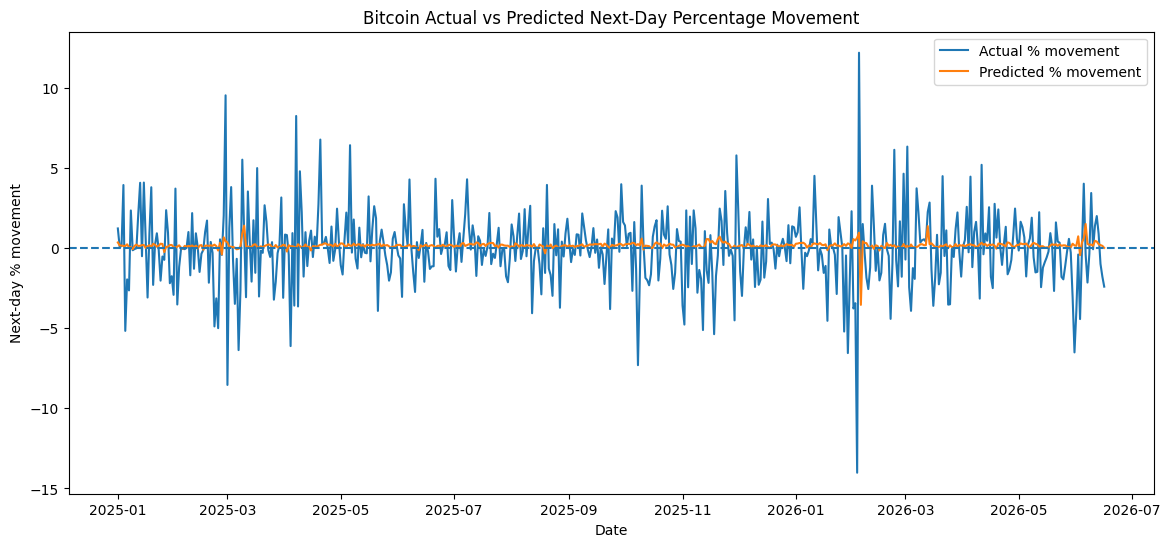

In [212]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(results["date"], results["target_pct"], label="Actual % movement")
plt.plot(results["date"], results["predicted_pct"], label="Predicted % movement")
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("Next-day % movement")
plt.title("Bitcoin Actual vs Predicted Next-Day Percentage Movement")
plt.legend()
plt.show()